<a href="https://colab.research.google.com/github/RatanShah7/Linked_List_Assignment/blob/master/HousePricePrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import joblib

In [3]:
print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [4]:
url = "https://raw.githubusercontent.com/Lokeshrathi/Bangalore-House-Prices/master/Bengaluru_House_Data.csv"

df = pd.read_csv(url)

df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [5]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 13320
Columns: 9


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [7]:
df.describe()

,bath,balcony,price
count,13247.000000,12711.000000,13320.000000
mean,2.692610,1.584376,112.565627
std,1.341458,0.817263,148.971674
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,72.000000
75%,3.000000,2.000000,120.000000
max,40.000000,3.000000,3600.000000


In [8]:
df.columns

Index(['area_type', 'availability', 'location', 'size', 'society',
       'total_sqft', 'bath', 'balcony', 'price'],
      dtype='object')

In [9]:
df.isnull().sum()

,0
area_type,0
availability,0
location,1
size,16
society,5502
total_sqft,0
bath,73
balcony,609
price,0


In [10]:
df = df.drop(["area_type", "availability", "society"], axis=1)

In [11]:
df.head()

,location,size,total_sqft,bath,balcony,price
0,Electronic City Phase II,2 BHK,1056,2.0,1.0,39.07
1,Chikka Tirupathi,4 Bedroom,2600,5.0,3.0,120.00
2,Uttarahalli,3 BHK,1440,2.0,3.0,62.00
3,Lingadheeranahalli,3 BHK,1521,3.0,1.0,95.00
4,Kothanur,2 BHK,1200,2.0,1.0,51.00


In [12]:
df["location"] = df["location"].fillna("Unknown")
df["size"] = df["size"].fillna("2 BHK")
df["bath"] = df["bath"].fillna(df["bath"].median())
df["balcony"] = df["balcony"].fillna(df["balcony"].median())

In [13]:
df["bhk"] = df["size"].str.extract("(\d+)").astype(float)

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_2964/2931866392.py:1: SyntaxWarning: invalid escape sequence '\d'
  df["bhk"] = df["size"].str.extract("(\d+)").astype(float)


In [14]:
df = df.drop("size", axis=1)

In [15]:
df.head()

,location,total_sqft,bath,balcony,price,bhk
0,Electronic City Phase II,1056,2.0,1.0,39.07,2.0
1,Chikka Tirupathi,2600,5.0,3.0,120.00,4.0
2,Uttarahalli,1440,2.0,3.0,62.00,3.0
3,Lingadheeranahalli,1521,3.0,1.0,95.00,3.0
4,Kothanur,1200,2.0,1.0,51.00,2.0


In [16]:
def convert_sqft(x):
    try:
        if "-" in str(x):
            values = str(x).split("-")
            return (float(values[0]) + float(values[1])) / 2
        return float(x)
    except:
        return np.nan

In [17]:
df["total_sqft"] = df["total_sqft"].apply(convert_sqft)

In [18]:
df = df.dropna(subset=["total_sqft", "bhk", "bath", "price"])

In [19]:
df.shape

(13274, 6)

In [20]:
df["price_per_sqft"] = df["price"] * 100000 / df["total_sqft"]

In [21]:
df = df[df["total_sqft"] / df["bhk"] >= 300]

In [22]:
def remove_pps_outliers(data):
    result = pd.DataFrame()

    for location, group in data.groupby("location"):
        mean = group.price_per_sqft.mean()
        std = group.price_per_sqft.std()

        filtered = group[
            (group.price_per_sqft >= mean - std) &
            (group.price_per_sqft <= mean + std)
        ]

        result = pd.concat([result, filtered], ignore_index=True)

    return result

In [23]:
df = remove_pps_outliers(df)

In [24]:
df = df[df["bath"] <= df["bhk"] + 2]

In [25]:
df = df.drop("price_per_sqft", axis=1)

In [26]:
df["location"] = df["location"].str.strip()

In [27]:
location_count = df["location"].value_counts()

rare_locations = location_count[location_count <= 10].index

df["location"] = df["location"].apply(
    lambda x: "other" if x in rare_locations else x
)

In [28]:
print("Final Dataset Shape:", df.shape)

df.head()

Final Dataset Shape: (9659, 6)


,location,total_sqft,bath,balcony,price,bhk
0,other,1100.0,2.0,1.0,70.0,2.0
1,other,1672.0,3.0,2.0,150.0,3.0
2,other,1750.0,3.0,3.0,149.0,3.0
3,other,1750.0,3.0,2.0,150.0,3.0
4,Devarachikkanahalli,1250.0,2.0,3.0,44.0,3.0


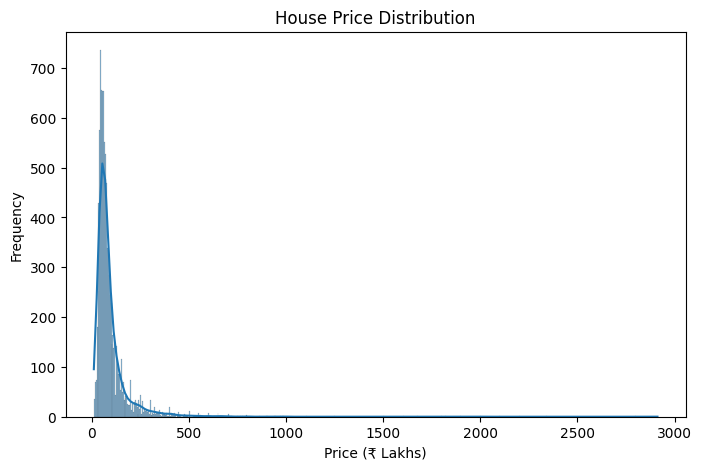

In [29]:
plt.figure(figsize=(8,5))

sns.histplot(df["price"], kde=True)

plt.xlabel("Price (₹ Lakhs)")
plt.ylabel("Frequency")
plt.title("House Price Distribution")

plt.show()

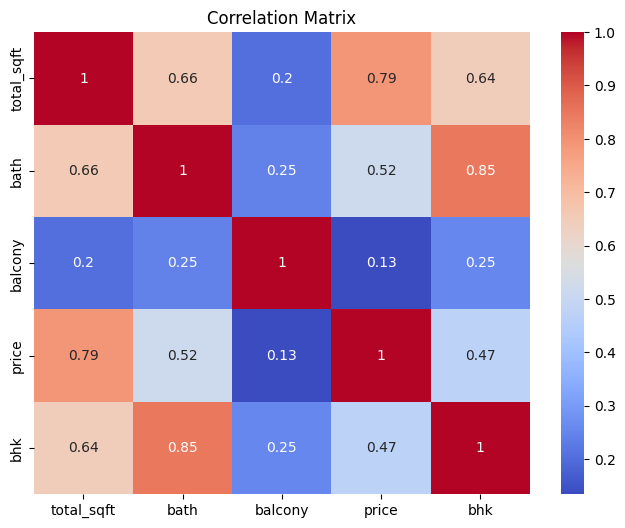

In [30]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [31]:
X = df.drop("price", axis=1)

y = df["price"]

In [32]:
X = pd.get_dummies(X, columns=["location"], drop_first=True)

In [33]:
X = X.astype(float)

In [34]:
print("Number of Features:", X.shape[1])

Number of Features: 185


In [35]:
X.head()

,total_sqft,bath,balcony,bhk,location_5th Phase JP Nagar,location_6th Phase JP Nagar,location_7th Phase JP Nagar,location_8th Phase JP Nagar,location_9th Phase JP Nagar,location_Abbigere,...,location_Varthur,location_Vidyaranyapura,location_Vijayanagar,location_Vittasandra,location_Whitefield,location_Yelachenahalli,location_Yelahanka,location_Yelahanka New Town,location_Yeshwanthpur,location_other
0,1100.0,2.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,1672.0,3.0,2.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1750.0,3.0,3.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1750.0,3.0,2.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,1250.0,2.0,3.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [37]:
print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

Training Samples: 7727
Testing Samples: 1932


In [38]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [39]:
model = Sequential([
    Dense(128, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [40]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [41]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        23,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,177 (133.50 KB)

 Trainable params: 34,177 (133.50 KB)

 Non-trainable params: 0 (0.00 B)

In [42]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

In [43]:
history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.20,
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
194/194 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 12255.1553 - mae: 54.1533 - val_loss: 11797.4834 - val_mae: 36.0113
Epoch 2/200
194/194 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 5791.2520 - mae: 31.6930 - val_loss: 8419.6309 - val_mae: 29.8055
Epoch 3/200
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 4680.8179 - mae: 28.6786 - val_loss: 7083.5259 - val_mae: 26.4461
Epoch 4/200
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 4117.8823 - mae: 26.9543 - val_loss: 6803.2158 - val_mae: 26.5794
Epoch 5/200
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 3774.7288 - mae: 26.5614 - val_loss: 6772.9316 - val_mae: 25.1050
Epoch 6/200
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 3332.7869 - mae: 26.1955 - val_loss: 7038.2305 - val_mae: 24.8184
Epoch 7/200
194/194 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 3534.2744 - mae: 25.6509 - val_loss: 7619.7725 - val_mae: 25.4350
Epoch 8/200
194/194 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 3192.2039 - mae: 25.1358 - val_loss: 8043.8970 -

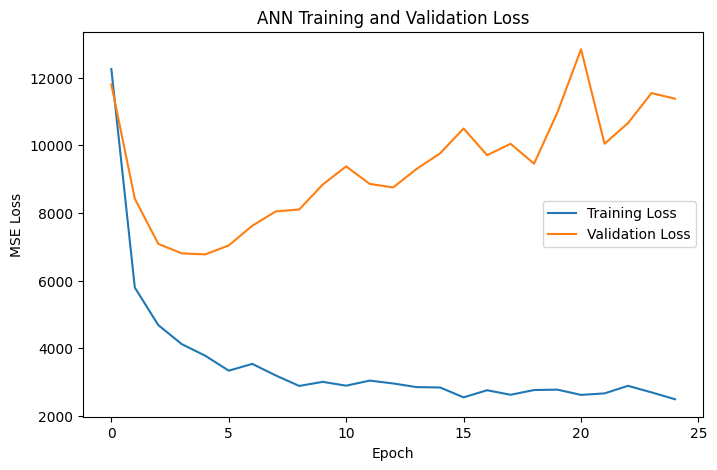

In [44]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("ANN Training and Validation Loss")
plt.legend()

plt.show()

In [45]:
y_pred = model.predict(X_test_scaled).flatten()

61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [46]:
r2 = r2_score(y_test, y_pred)

print(f"R2 Score: {r2:.4f}")

R2 Score: 0.7167


In [47]:
mae = mean_absolute_error(y_test, y_pred)

print(f"MAE: ₹{mae * 100000:,.0f}")

MAE: ₹2,250,485


In [48]:
mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

print(f"RMSE: ₹{rmse * 100000:,.0f}")

RMSE: ₹5,668,642


In [49]:
percentage_error = np.abs((y_test - y_pred) / y_test)

accuracy_10 = np.mean(percentage_error <= 0.10) * 100

print(f"Prediction Accuracy (within ±10%): {accuracy_10:.2f}%")

Prediction Accuracy (within ±10%): 32.45%


In [50]:
print("=" * 50)
print("ANN HOUSE PRICE PREDICTION RESULTS")
print("=" * 50)

print(f"R2 Score                       : {r2:.4f}")
print(f"R2 Performance                 : {r2 * 100:.2f}%")
print(f"Prediction Accuracy (±10%)     : {accuracy_10:.2f}%")
print(f"MAE                            : ₹{mae * 100000:,.0f}")
print(f"RMSE                           : ₹{rmse * 100000:,.0f}")

print("=" * 50)

ANN HOUSE PRICE PREDICTION RESULTS
R2 Score                       : 0.7167
R2 Performance                 : 71.67%
Prediction Accuracy (±10%)     : 32.45%
MAE                            : ₹2,250,485
RMSE                           : ₹5,668,642


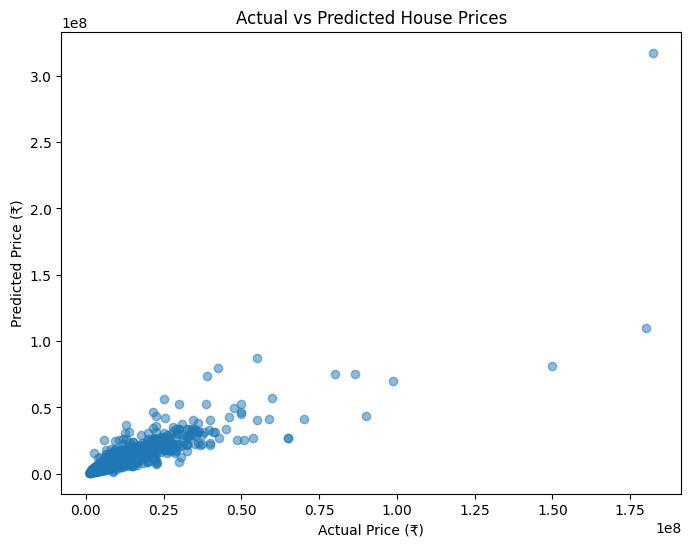

In [51]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test * 100000,
    y_pred * 100000,
    alpha=0.5
)

plt.xlabel("Actual Price (₹)")
plt.ylabel("Predicted Price (₹)")
plt.title("Actual vs Predicted House Prices")

plt.show()

In [52]:
results = pd.DataFrame({
    "Actual Price (₹)": y_test.values * 100000,
    "Predicted Price (₹)": y_pred * 100000
})

results["Actual Price (₹)"] = results["Actual Price (₹)"].round(0)
results["Predicted Price (₹)"] = results["Predicted Price (₹)"].round(0)

results.head(10)

,Actual Price (₹),Predicted Price (₹)
0,9800000.0,8187416.0
1,10000000.0,11441196.0
2,7000000.0,13257716.0
3,13100000.0,11320599.0
4,4800000.0,5537410.0
5,6700000.0,6050802.0
6,5899000.0,5886959.0
7,10500000.0,10001412.0
8,4495000.0,3056666.0
9,3900000.0,3637703.0


In [53]:
results["Error (₹)"] = (
    results["Actual Price (₹)"] -
    results["Predicted Price (₹)"]
)

results.head(10)

,Actual Price (₹),Predicted Price (₹),Error (₹)
0,9800000.0,8187416.0,1612584.0
1,10000000.0,11441196.0,-1441196.0
2,7000000.0,13257716.0,-6257716.0
3,13100000.0,11320599.0,1779401.0
4,4800000.0,5537410.0,-737410.0
5,6700000.0,6050802.0,649198.0
6,5899000.0,5886959.0,12041.0
7,10500000.0,10001412.0,498588.0
8,4495000.0,3056666.0,1438334.0
9,3900000.0,3637703.0,262297.0


In [54]:
new_house = {
    "location": "Whitefield",
    "total_sqft": 1200,
    "bath": 2,
    "balcony": 1,
    "bhk": 2
}

In [55]:
new_house_df = pd.DataFrame([new_house])

In [56]:
new_house_encoded = pd.get_dummies(
    new_house_df,
    columns=["location"],
    drop_first=True
)

In [57]:
new_house_encoded = new_house_encoded.reindex(
    columns=X.columns,
    fill_value=0
)

In [58]:
new_house_scaled = scaler.transform(new_house_encoded)

In [59]:
prediction = model.predict(new_house_scaled)[0][0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step


In [60]:
prediction_rupees = prediction * 100000

print(f"Predicted House Price: ₹{prediction_rupees:,.0f}")

Predicted House Price: ₹2,119,088


In [61]:
model.save("bangalore_house_price_ann.keras")

In [62]:
joblib.dump(scaler, "house_price_scaler.pkl")

['house_price_scaler.pkl']

In [63]:
joblib.dump(X.columns.tolist(), "house_price_features.pkl")

['house_price_features.pkl']